데이터 셋 소환

In [1]:
import torch
from torchvision.datasets import CIFAR100
from torchvision.transforms import v2

In [3]:
custom_transform= v2.Compose([
       v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
])

#학습 및 테스트 데이터 세트 다운

train_dataset = CIFAR100(root="../data02", train=True, download=True, transform=custom_transform)
test_dataset = CIFAR100(root="../data02", train=False, download=True, transform=custom_transform)

100%|██████████| 169M/169M [00:15<00:00, 10.9MB/s] 


In [4]:
print(train_dataset)


Dataset CIFAR100
    Number of datapoints: 50000
    Root location: ../data02
    Split: Train
    StandardTransform
Transform: Compose(
                 Compose(
                   ToImage()
                   ToDtype(scale=True)
             )
           )


In [5]:
print(test_dataset)

Dataset CIFAR100
    Number of datapoints: 10000
    Root location: ../data02
    Split: Test
    StandardTransform
Transform: Compose(
                 Compose(
                   ToImage()
                   ToDtype(scale=True)
             )
           )


[0] 첫번째 사진 소환

In [6]:
# 첫 번째 데이터 샘플 불러오기
image, label = train_dataset[0]

# 이미지와 레이블 정보 출력
print(f"image.shape : {image.shape}")
print(f"label : {label}")

image.shape : torch.Size([3, 32, 32])
label : 19


숫자 라벨 -> 사람이 읽을 수 있는 이름으로 바꾸기
레이블 이름 로드하는 함수 만들었어.
라인 하나씩 가지고 와서 strip으로 글자를 잘라서 라인에  넣고, if true이면": "으로 strip 하고 key, value 함
key와 value 값이 들어가는 라벨 이름을 만들어.


In [10]:
import urllib.request
# 레이블 이름 로드 함수 정의
def load_label_names(file_path):
    label_names = {}
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if line:
                key, value = line.split(": ")
                key = int(key)
                label_names[key] = value
    return label_names

# 파일 다운로드
file_url = "https://drive.google.com/uc?export=download&id=18xAbQshFxDKs8ItjwEPdV6M2hLyF61ZY"
file_name = "label_names.txt"
urllib.request.urlretrieve(file_url, file_name)

# 레이블 이름 불러오기
label_names = load_label_names(file_name)

# 딕셔너리 확인
print(label_names)

{0: 'apple', 1: 'aquarium_fish', 2: 'baby', 3: 'bear', 4: 'beaver', 5: 'bed', 6: 'bee', 7: 'beetle', 8: 'bicycle', 9: 'bottle', 10: 'bowl', 11: 'boy', 12: 'bridge', 13: 'bus', 14: 'butterfly', 15: 'camel', 16: 'can', 17: 'castle', 18: 'caterpillar', 19: 'cattle', 20: 'chair', 21: 'chimpanzee', 22: 'clock', 23: 'cloud', 24: 'cockroach', 25: 'couch', 26: 'cra', 27: 'crocodile', 28: 'cup', 29: 'dinosaur', 30: 'dolphin', 31: 'elephant', 32: 'flatfish', 33: 'forest', 34: 'fox', 35: 'girl', 36: 'hamster', 37: 'house', 38: 'kangaroo', 39: 'keyboard', 40: 'lamp', 41: 'lawn_mower', 42: 'leopard', 43: 'lion', 44: 'lizard', 45: 'lobster', 46: 'man', 47: 'maple_tree', 48: 'motorcycle', 49: 'mountain', 50: 'mouse', 51: 'mushroom', 52: 'oak_tree', 53: 'orange', 54: 'orchid', 55: 'otter', 56: 'palm_tree', 57: 'pear', 58: 'pickup_truck', 59: 'pine_tree', 60: 'plain', 61: 'plate', 62: 'poppy', 63: 'porcupine', 64: 'possum', 65: 'rabbit', 66: 'raccoon', 67: 'ray', 68: 'road', 69: 'rocket', 70: 'rose', 7

이미지를 불러오자. 맵플롭립 충돌방지 코드 넣기

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

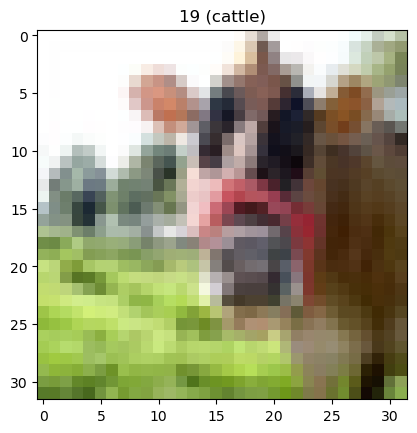

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'


# 첫 번째 데이터 시각화
image, label = train_dataset[0]

# 텐서를 넘파이 배열로 변환 (채널, 높이, 너비)
image = image.numpy()

# (채널, 높이, 너비)를 (높이, 너비, 채널)로 변환 !!! 추가 공부하기 
image = np.transpose(image, (1, 2, 0))

# 이미지 및 레이블 시각화
plt.title(f"{label} ({label_names[label]})")
plt.imshow(image)
plt.show()

여러 이미지 시각화

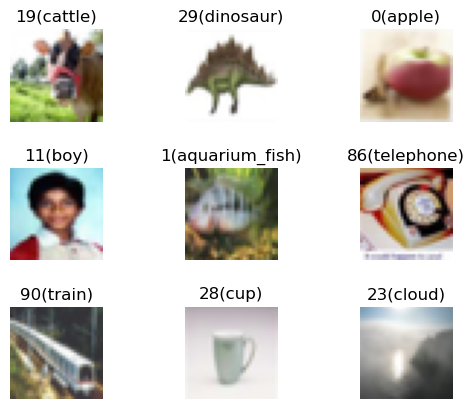

In [14]:
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.axis('off')
    plt.subplots_adjust(hspace=0.5)
    plt.title(f'{train_dataset[i][1]}({label_names[train_dataset[i][1]]})')
    plt.imshow(train_dataset.data[i])
plt.show()

데이터 전처리

이미지의 크기 조절이 필요. 우리가 다운 받는건 일정한 크기가 아니야.
학습 데이터 세트와 테스트 데이터 세트에 대한 데이터 전처리를 진행합니다. 전처리는 이미지 크기 조정, 데이터 증강, 정규화 등 다양한 방법으로 이루어지며, 이는 모델의 성능을 향상시키기 위한 중요한 단계입니다.

v2.Resize((224, 224)): ResNet50의 입력 크기에 맞게 이미지를 (224, 224)로 변환합니다.
v2.RandomHorizontalFlip(p=0.5): 50% 확률로 이미지를 좌우로 뒤집어 데이터 증강을 진행합니다.
v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]): 이미지를 텐서로 변환하고, 0과 1 사이의 값으로 스케일링합니다.
v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]): 평균값과 표준편차를 사용해 이미지 정규화를 수행합니다.
테스트 데이터 세트의 전처리 과정은 다음과 같습니다.

v2.Resize((224, 224)): 이미지 크기를 (224, 224)로 변환합니다.
v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]): 이미지를 텐서로 변환하고, 0과 1 사이의 값으로 스케일링합니다.
v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]): 정규화를 적용합니다.

폴더 이미지는 전처리 필수!!!

In [15]:
import torch
from torchvision.transforms import v2

# 학습 데이터 세트 전처리
train_transform = v2.Compose([
    v2.Resize((224, 224)),  # 이미지 크기 변환
    v2.RandomHorizontalFlip(p=0.5),  # 좌우 반전
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),  # 텐서 변환 및 스케일링
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 정규화
])

# 테스트 데이터 세트 전처리
test_transform = v2.Compose([
    v2.Resize((224, 224)),  # 이미지 크기 변환
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),  # 텐서 변환 및 스케일링
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # 정규화
])


트랜스폼 해서 해서 로드.

앞에는 (3, 32, 32)였는데 트랜스폼하니 (3, 224, 224)됨

In [17]:
# 첫 번째 데이터 샘플 불러오기
image, label = train_dataset[0]

# 이미지와 레이블 정보 출력
print(f"image.shape : {image.shape}")
print(f"label : {label}")

image.shape : torch.Size([3, 224, 224])
label : 19


In [18]:
from torchvision.datasets import CIFAR100

# CIFAR-100 데이터 세트 다운로드 및 전처리 적용
train_dataset = CIFAR100(root="../data02", train=True, download=True, transform=train_transform)
test_dataset = CIFAR100(root="../data02", train=False, download=True, transform=test_transform)


데이터로더 준비하기
32개씩 가지고 와서 연산

In [19]:
from torch.utils.data.dataloader import DataLoader

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


테스트든 트레인이든 하나 가지고 와서 하나의 배치가 32개인걸 확인함.

In [20]:
for X, Y in train_dataloader:
  print(X.size(), Y.size())
  break

torch.Size([32, 3, 224, 224]) torch.Size([32])


학습시킨다.
ResNet50 모델의 분류기 구조는 기본적으로 다음과 같이 정의됩니다.
기존의 cnn은 컨볼루션+렐루+풀링 신경망으로 반복

우리는 이 모델을 고쳐써야해.

model.fc = nn.Sequential(
    nn.Linear(in_features=model.fc.in_features, out_features=512), 
    nn.ReLU(inplace=True),
    nn.Linear(in_features=512, out_features=64),
    nn.ReLU(inplace=True),
    nn.Linear(in_features=64, out_features=num_classes),
)

이 구조를 바탕으로 학습 모델을 정의해.

분류기 수정

ResNet50 기본 입력이 보통 (3, 224, 224) 로 설계
image.shape : [3, 224, 224] 이건 ResNet50에 딱 맞는 형태임.

단, 모델에 넣을 땐 “배치 차원”이 필요해서
(1, 3, 224, 224) 또는 (batch, 3, 224, 224) 여야 해


model.fc를 바꾸는 이유 (핵심)
ResNet50은 원래 ImageNet용이라 마지막이 보통: 1000개 클래스 분류(fc)로 되어 있어.

근데 열시 데이터는 지금 라벨이 0~99라서 👉 클래스 수 = 100개 (num_classes=100)
그래서 마지막 출력층을 100개로 바꿔야 해.

마지막 Linear의 out_features = 내 클래스 수
nn.Linear(in_features=64, out_features=num_classes)  # num_classes=100


7) 그럼 “512, 64”를 바꾸는 상황은 언제야?

이건 감으로 가면 안 되고, 증상으로 판단해.

학습 정확도는 엄청 높은데 테스트 정확도 낮다 → 과적합
👉 중간층 줄이기 (512→256, 64 삭제 등) / dropout 추가

둘 다 정확도가 낮다 → 모델이 충분히 못 배움(언더핏)
👉 중간층 늘리기 / 학습률, 데이터 증강 점검

즉, 512/64는 데이터 모양 때문이 아니라 학습 결과 때문에 조절해.

In [21]:
import torch
import torch.nn as nn #nn이 있어야지 모델만들 수 있어
from torchvision.models import resnet50, ResNet50_Weights #models 는 첨써 우린 직접 만들어썼으니, 훈련된 weights(w) 가지고 와.

# 디바이스 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# 클래스 개수
num_classes = 100

# ResNet50 모델 불러오기
model = resnet50(weights=ResNet50_Weights.DEFAULT) #설정된 디폴트 값으로 resnet50모델을 만들어줘

# 모델의 분류기 구조 변경
model.fc = nn.Sequential( 
    nn.Linear(in_features=model.fc.in_features, out_features=512),
    nn.ReLU(inplace=True),
    nn.Linear(in_features=512, out_features=64),
    nn.ReLU(inplace=True),
    nn.Linear(in_features=64, out_features=num_classes),
)

# 모델을 GPU나 CPU로 이동
model.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\it/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

모델 출력
모양이 CNN이야. CON -> RELU -> POOL

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)  

... 중간 생략 ...

모델 정의야. 기존 모델에서 그대로 쓸 수 없어.
모델을 바꾸고 우리의 데이터로 훈련시켜야해.

  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=100, bias=True)
  )
)


손실 함수, 최적화 함수

소프트맥스 생략하고 손실함수가 CrossEntropyLoss라서 생략
최적화 함수는 Adam

In [22]:
from torch.optim import Adam

# 학습률(Learning Rate)
lr = 1e-4

# 손실 함수 정의
criterion = nn.CrossEntropyLoss()

# 최적화 함수 정의
optimizer = Adam(model.parameters(), lr=lr)


다음 코드에서는 앞서 정의한 데이터로더, 학습 모델, 손실 함수, 최적화 함수를 사용하여 학습을 진행합니다. 

tqdm 라이브러리를 사용해 각 에포크(epoch)마다 학습과 테스트를 번갈아 진행하며, 학습 진행 상황을 시각화합니다.



In [23]:
import numpy as np
from tqdm import tqdm

# 에포크 수 설정
num_epochs = 5
train_acc = [] #정확도
train_loss = [] #손실함수
test_acc = []
test_loss = []

for epoch in range(num_epochs):
    # 학습 모드 설정
    model.train() #모드 설정
    running_train_acc = 0 #한 에폭 돌때마다 정확도 
    running_train_loss = 0 
    train_dataset_count = len(train_dataloader.dataset) #전체 개수

    # 배치 1개 가지고 오는 것 학습 단계 50000 / 32 수 만큼 학습
    for images, labels in tqdm(train_dataloader): #로드에서 이미지와 라벨을 가지고 와서
        # 기울기 초기화
        optimizer.zero_grad() 

        # 데이터와 레이블을 디바이스로 이동
        images = images.to(device) #쿠다 포함 설정
        labels = labels.to(device)

        # 모델 예측
        outputs = model(images)

        # 손실 계산
        loss = criterion(outputs, labels) 

        # 오차 역전파
        loss.backward()

        # 최적화 진행
        optimizer.step()

        # 예측값에서 가장 높은 확률의 값 선택
        _, predicted = torch.max(outputs.data, 1) #예측값에서 가장 높은 확률 것 선택

        # 정확도 계산
        running_train_acc += predicted.eq(labels).sum().item() # eqs 나 = 같고,

        # 손실 누적
        running_train_loss += loss.item() * images.size(0)

    # 학습 정확도와 손실 저장
    train_acc.append(running_train_acc / train_dataset_count) 
    train_loss.append(running_train_loss / train_dataset_count)

    # 검증 단계
    model.eval() #모델학습 nod 사이 링크, 25% 랜덤하게 하는데 eval 하면 drop 안하고 검증모드?
    running_test_acc = 0
    running_test_loss = 0
    test_dataset_count = len(test_dataloader.dataset)

    with torch.no_grad(): #기울기 연산안함
        for images, labels in tqdm(test_dataloader):
            # 데이터와 레이블을 디바이스로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 모델 예측
            outputs = model(images)

            # 손실 계산
            loss = criterion(outputs, labels)

            # 예측값에서 가장 높은 확률의 값 선택
            _, predicted = torch.max(outputs.data, 1)

            # 정확도 계산
            running_test_acc += predicted.eq(labels).sum().item()

            # 손실 누적
            running_test_loss += loss.item() * images.size(0)

    # 테스트 정확도와 손실 저장
    test_acc.append(running_test_acc / test_dataset_count)
    test_loss.append(running_test_loss / test_dataset_count)

    # 에포크 결과 출력
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss[-1]:.4f}, Train Accuracy: {train_acc[-1]:.4f}, Test Loss: {test_loss[-1]:.4f}, Test Accuracy: {test_acc[-1]:.4f}")


 26%|██▋       | 412/1563 [43:39<2:01:58,  6.36s/it]


KeyboardInterrupt: 

평가

In [ ]:
total = 0
correct = 0

# 모델을 평가 모드로 설정 (기울기 계산 비활성화)
model.eval()

with torch.no_grad():    
    for images, labels in tqdm(test_dataloader):
        # 데이터와 레이블을 디바이스로 이동
        images = images.to(device)
        labels = labels.to(device)

        # 모델 예측
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        # 전체 데이터 개수 계산
        total += labels.size(0)

        # 맞춘 개수 누적
        correct += (predicted == labels).sum().item()

# 최종 정확도 계산 및 출력
accuracy = correct / total 
print(f'Accuracy on test set: {accuracy:.4f}')
